In [1]:
import pandas as pd
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]

In [3]:
print(x.isnull().sum())

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


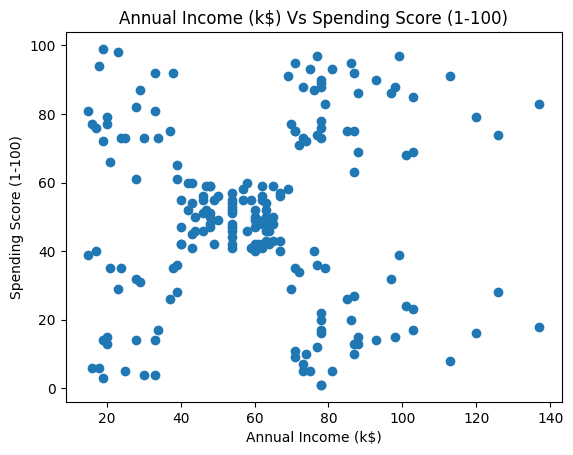

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x.iloc[:,0],x.iloc[:,1])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income (k$) Vs Spending Score (1-100)')
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

In [6]:
from sklearn.cluster._dbscan import DBSCAN
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(x_scaled)

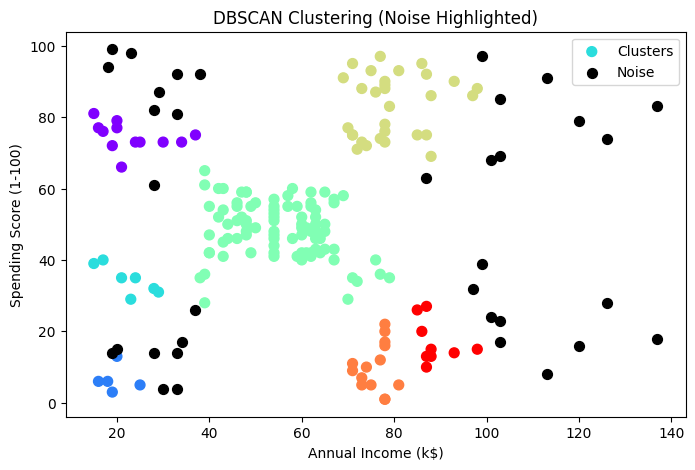

In [9]:
# plt.figure(figsize=(12,5))
# plt.scatter(x.iloc[clusters!=1,0],x.iloc[clusters!=1,1],c=clusters[clusters!=-1],cmap='rainbow',s=50,label='Clusters')
# plt.scatter(x.iloc[clusters==-1,0],x.iloc[clusters==-1,1],s=50,c='black',label='Noise')
# plt.xlabel('Annual Income (k$)')
# plt.ylabel('Spending Score (1-100)')
# plt.title('Clusters')
# plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot clusters (excluding noise)
plt.scatter(
    x.loc[clusters != -1, 'Annual Income (k$)'],
    x.loc[clusters != -1, 'Spending Score (1-100)'],
    c=clusters[clusters != -1],
    cmap='rainbow',
    s=50,
    label='Clusters'
)

# Plot noise points
plt.scatter(
    x.loc[clusters == -1, 'Annual Income (k$)'],
    x.loc[clusters == -1, 'Spending Score (1-100)'],
    c='black',
    s=50,
    label='Noise'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering (Noise Highlighted)')
plt.legend()
plt.show()


ValueError: 'c' argument has 165 elements, which is inconsistent with 'x' and 'y' with size 195.

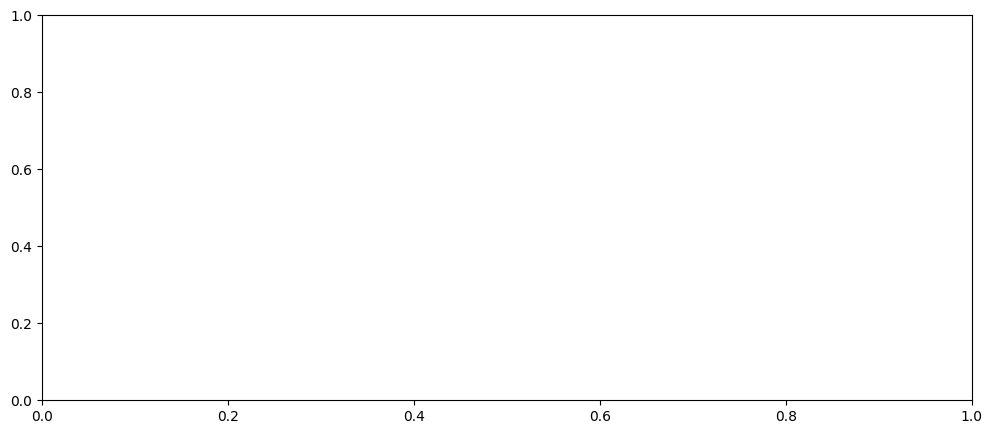

In [8]:
plt.figure(figsize=(12,5))
plt.scatter(x.iloc[clusters!=1,0],x.iloc[clusters!=1,1],c=clusters[clusters!=-1],cmap='rainbow',s=50,label='Clusters')
plt.scatter(x.iloc[clusters==-1,0],x.iloc[clusters==-1,1],s=50,c='black',label='Noise')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters')
plt.show()

In [ ]:
print(x_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

In [ ]:
# After DBSCAN:

# labels = db.fit_predict(x_scaled)


# Suppose you have 10 data points:

# Index:   0   1   2   3   4   5   6   7   8   9
# labels:  0   0  -1   1   1   1  -1   0   0  -1

# 2️⃣ What does this line do?
# mask = labels != -1


# This creates a boolean mask:

# mask = [
#  True,  # 0
#  True,  # 1
#  False, # 2 (noise)
#  True,  # 3
#  True,  # 4
#  True,  # 5
#  False, # 6 (noise)
#  True,  # 7
#  True,  # 8
#  False  # 9 (noise)
# ]


# 👉 True = keep
# 👉 False = remove

# 3️⃣ How masking works on x_scaled

# Suppose your data looks like:

# x_scaled =
# [
#  [1.2, 3.4],  # index 0
#  [1.1, 3.5],  # index 1
#  [9.9, 8.8],  # index 2 (noise)
#  [5.2, 6.1],  # index 3
#  [5.1, 6.0],  # index 4
#  [5.3, 6.2],  # index 5
#  [9.8, 8.7],  # index 6 (noise)
#  [1.3, 3.3],  # index 7
#  [1.4, 3.2],  # index 8
#  [9.7, 8.9]   # index 9 (noise)
# ]


# Now apply:

# x_scaled[mask]


# Result:

# [
#  [1.2, 3.4],  # index 0
#  [1.1, 3.5],  # index 1
#  [5.2, 6.1],  # index 3
#  [5.1, 6.0],  # index 4
#  [5.3, 6.2],  # index 5
#  [1.3, 3.3],  # index 7
#  [1.4, 3.2]   # index 8
# ]
# # 4️⃣ Masking labels the same way
# labels[mask]


# Result:

# [0, 0, 1, 1, 1, 0, 0]


# Now:

# Data points

# Cluster labels

# are perfectly aligned.

# 5️⃣ Why silhouette NEEDS this

# Silhouette score formula:

#     s(i)=(b(i)-a(i))/max(a(i),b(i))


# Where:

# a(i) = distance within cluster

# b(i) = distance to nearest other cluster

# ❌ Noise (-1) has:

# No cluster

# No centroid

# No meaning

# So this is invalid:

# silhouette_score(x_scaled, labels)  ❌

# But this is correct:

# silhouette_score(x_scaled[mask], labels[mask]) ✅

# 6️⃣ Key intuition (very important)

# Masking does not compare values
# Masking filters rows by index alignment

# Row i in x_scaled

# Label i in labels

# Mask at index i

# All move together.

In [ ]:
from sklearn.metrics import silhouette_score
eps=[0.2,0.3,0.5]
for ep in eps:
    db=DBSCAN(eps=ep,min_samples=5)
    labels=db.fit_predict(x_scaled)
    unique_Labels=set(labels)
    n_clusters=len(unique_Labels)-(1 if -1 in unique_Labels else 0)
    # print(labels)
    # print(unique_Labels)
    n_noise=list(labels).count(-1)
    n_ratio=n_noise/len(labels)
    print("no. of clusters: ",n_clusters)
    print("noise points ratio: ",round(n_ratio,3))
    if n_clusters>=2:
        mask=labels!=-1
        print("silhouette score: ",round(silhouette_score(x_scaled[mask],labels[mask]),2))

no. of clusters:  7
noise points ratio:  0.385
silhouette score:  0.3
no. of clusters:  7
noise points ratio:  0.175
silhouette score:  0.52
no. of clusters:  2
noise points ratio:  0.04
silhouette score:  0.44
